# DETECTION DI RED CLUMP VISIBILI DAL TELESCOPIO EUCLID NELLA BANDA J 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import norm

Apro e leggo le prime righe del dataset contenente la simulazione fatta con il modello di Besancon con:
- l = 1.0, b = 0.0
- f.o.v. = 1 deg^2
- 10 < J < 21
- con estinzione

In [2]:
from astropy.io import fits

# Apro il file FITS
with fits.open(r"D:\Master TO\Tirocinio INAF\Simulazioni\Simulazioni Besancon\CG, sì estinzione\l = 1.0, b = 0.0, J da 10 a 21.fits") as hdul:
    data = hdul[1].data  # Assuming the table is in the first extension

# Convert to pandas DataFrame
df_fits = pd.DataFrame(np.array(data))
print(df_fits.head())

           V    B-V    V-I    V-J    V-H        mux        muy        HRV  \
0  18.365999  1.763  3.180  5.008  5.599 -56.797001 -77.777000 -46.099998   
1  16.358999  1.454  2.527  3.998  4.557 -15.546000 -32.129002 -58.910000   
2  18.705000  1.634  2.905  4.607  5.217  10.987000 -38.523998 -26.750000   
3  19.330999  1.714  3.041  4.750  5.415  28.107000  -9.628000  -2.060000   
4  19.420000  1.635  3.013  4.698  5.299 -16.264999  24.243999  43.230000   

          UU         VV  ...  errAge  errTeff  errLogg  errMet  errAlphaFe  \
0 -45.049999 -21.459999  ...     0.1     50.0      0.1     0.1        0.02   
1 -61.660000 -12.610000  ...     0.1     50.0      0.1     0.1        0.02   
2 -26.990000 -12.830000  ...     0.1     50.0      0.1     0.1        0.02   
3  -2.420000   3.540000  ...     0.1     50.0      0.1     0.1        0.02   
4  43.160000   6.170000  ...     0.1     50.0      0.1     0.1        0.02   

   errBand_V  errBand_B  errBand_I  errBand_J  errBand_H  
0     0.0

Let's define first the RC subsets. I use the following range:
- 4500 < Teff < 5500
- -0.6 < [Fe/H] < 0.4
- 0.9 < Mv < 1.3
- 1 < logg < 3

This is not a precise identification of the red clump stars.

In [3]:
# Ensure all columns are in native endianness
df_fits_native = df_fits.copy()
for col in df_fits_native.columns:
    arr = df_fits_native[col].values
    if arr.dtype.byteorder not in ('=', '|'):
        df_fits_native[col] = arr.byteswap().newbyteorder()

# Filtro tutte le stelle per trovare quelle appartenenti al sottoinsieme delle RC 
RC = df_fits_native[
    (df_fits_native['Teff'] > 4500) & (df_fits_native['Teff'] < 5500) &
    (df_fits_native['[M/H]'] > -0.6) & (df_fits_native['[M/H]'] < 0.4) &
    (df_fits_native['Mv'] > 0.9) & (df_fits_native['Mv'] < 1.3) &
    (df_fits_native['logg'] > 1) & (df_fits_native['logg'] < 3)
]

In [4]:
print(RC.head(), RC.shape)
print(f"The Red Clump stars are {len(RC)} out of {len(df_fits_native)} total stars, which is {len(RC)/len(df_fits_native)*100:.2f}% of the total.")

            V    B-V    V-I    V-J    V-H    mux    muy        HRV         UU  \
42935  14.142  1.880  2.008  3.498  4.258  1.014 -4.120   2.210000  -0.920000   
46843  12.994  1.563  1.609  2.787  3.526 -1.990 -5.999  -3.160000  -2.440000   
53064  14.207  1.802  2.002  3.403  4.194  2.052 -1.609 -86.120003 -85.940002   
53134  14.256  1.803  1.967  3.421  4.201  0.616 -5.001 -22.180000 -21.260000   
62373  15.218  2.080  2.213  3.896  4.742  1.372 -0.397   9.280000   8.010000   

          VV  ...  errAge  errTeff  errLogg  errMet  errAlphaFe  errBand_V  \
42935 -15.93  ...     0.1     50.0      0.1     0.1        0.02     0.0252   
46843 -41.23  ...     0.1     50.0      0.1     0.1        0.02     0.0162   
53064  -6.29  ...     0.1     50.0      0.1     0.1        0.02    -0.0019   
53134 -23.18  ...     0.1     50.0      0.1     0.1        0.02     0.0055   
62373  -5.02  ...     0.1     50.0      0.1     0.1        0.02    -0.0284   

       errBand_B  errBand_I  errBand_J  errB

Now, let's consider circle of radius 0.5 arcsec around each RC star. If it's present a star * with 

- smaller magnitude (so more luminous);
- larger magnitude but of only 2 degree,

then the luminosity of * makes the RC undetectable from the telescope so we discard it.
Otherwise, keep it.

We take only RC with J < 19.

In [5]:
# Use RC from previous cell and filter for J < 19
RC_J = RC[(RC["V"] - RC["V-J"]) < 19].copy() # This line selects a subset of red clump (RC) stars from the existing DataFrame RC. 
# The filter keeps only those stars where J is less than 19. The .copy() ensures that
#further modifications to RC_J don’t affect the original RC DataFrame.

# Use cKDTree for efficient neighbor search
from scipy.spatial import cKDTree

# Prepare coordinates in degrees
rc_coords = np.vstack([RC_J["longitude"].values, RC_J["latitude"].values]).T
all_coords = np.vstack([df_fits_native["longitude"].values, df_fits_native["latitude"].values]).T

# Build KDTree for all stars
tree = cKDTree(all_coords)

# Search for all neighbors within 0.5 arcsec (1/3600 deg)
idx_neighbors = tree.query_ball_point(rc_coords, r=1/7200)


Le RC con J < 19 sono:

In [6]:
print(f"{len(RC_J)} ({len(RC_J)/len(RC)*100:.2f}%)")

66993 (48.96%)


In [7]:
# Prepare mask for RC stars that are "seen"
keep_mask = np.ones(len(RC_J), dtype=bool)

rc_mags = RC_J["V"].values - RC_J["V-J"].values
all_mags = df_fits_native["V"].values - df_fits_native["V-J"].values

for i, neighbors in enumerate(idx_neighbors):
	# Remove self-match if present
	neighbors = [n for n in neighbors if n != RC_J.index[i]]
	if not neighbors:
		continue
	neighbor_mags = all_mags[neighbors]
	rc_mag = rc_mags[i]
	# If any neighbor is brighter or within 2 mag, mark as not seen
	if ((neighbor_mags < rc_mag) | (neighbor_mags < rc_mag + 2)).any():
		keep_mask[i] = False

RC_J_seen = RC_J[keep_mask]
percentage_seen = len(RC_J_seen) / len(RC_J) * 100
print(f"Le RC con J < 19 e non coperte da altre stelle luminose sono {len(RC_J_seen)}, ovvero il {percentage_seen:.2f}% delle RC con J < 19.")

Le RC con J < 19 e non coperte da altre stelle luminose sono 59642, ovvero il 89.03% delle RC con J < 19.


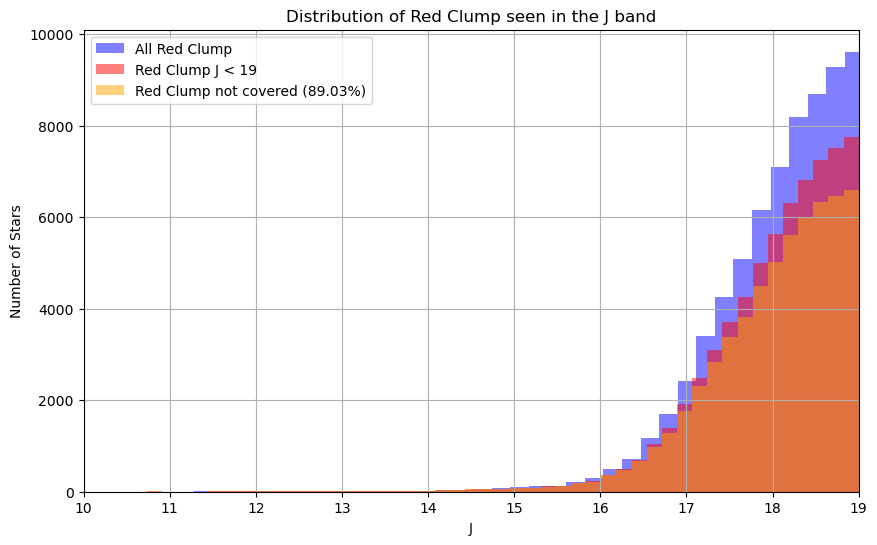

In [8]:
plt.figure(figsize=(10,6))

plt.hist(RC["V"].values - RC["V-J"].values, bins=50, alpha=0.5, label='All Red Clump', color='blue')
plt.hist(RC_J["V"].values - RC_J["V-J"].values, bins=50, alpha=0.5, label='Red Clump J < 19', color='red')
plt.hist(RC_J_seen["V"].values - RC_J_seen["V-J"].values, bins=50, alpha=0.5, label=f'Red Clump not covered ({percentage_seen:.2f}%)', color='orange')
#plt.hist(df_fits_native["V"].values - df_fits_native["V-J"].values, bins=50, alpha=0.5, label='All Stars', color='green')

plt.xlabel('J')
plt.xlim(10, 19)
plt.ylabel('Number of Stars')
plt.title('Distribution of Red Clump seen in the J band')
plt.legend()
plt.grid()
plt.show()

# Faccio la stessa cosa per le red clump con I fino a 21.

In [9]:
# Use RC from previous cell and filter for I < 21
RC_I = RC[(RC["V"] - RC["V-I"]) < 21].copy()

# Prepare coordinates for RC_sel_I
rc_coords_I = np.vstack([RC_I["longitude"].values, RC_I["latitude"].values]).T
all_coords = np.vstack([df_fits_native["longitude"].values, df_fits_native["latitude"].values]).T

tree = cKDTree(all_coords)
idx_neighbors_I = tree.query_ball_point(rc_coords_I, r=1/3600)

# Prepare mask for RC stars that are "seen" in the I band
mask_I = np.ones(len(RC_I), dtype=bool)

rc_I_mags = RC_I["V"].values - RC_I["V-I"].values
all_I_mags = df_fits_native["V"].values - df_fits_native["V-I"].values

# RC_sel_I.index gives the original indices in df_fits_native
rc_sel_i_indices = RC_I.index.values
print(f"The number of RC with I < 21 is: {len(RC_I)}")


The number of RC with I < 21 is: 3610


In [10]:

for i, neighbors in enumerate(idx_neighbors_I):
	# Remove self-match if present (neighbor indices are in df_fits_native index space)
	neighbors = [n for n in neighbors if n != rc_sel_i_indices[i]]
	if not neighbors:
		continue
	neighbor_mags = all_I_mags[neighbors]
	rc_I_mag = rc_I_mags[i]
	# If any neighbor is brighter or within 2 mag, mark as not seen
	if ((neighbor_mags < rc_I_mag) | (neighbor_mags < rc_I_mag + 2)).any():
		mask_I[i] = False

RC_I_seen = RC_I[mask_I]
print(len(RC_I_seen))

2883


In [11]:
percentage = len(RC_I_seen) / len(RC) * 100
print(f"Percentage of RC stars seen in the I band: {percentage:.2f}%")

Percentage of RC stars seen in the I band: 2.11%


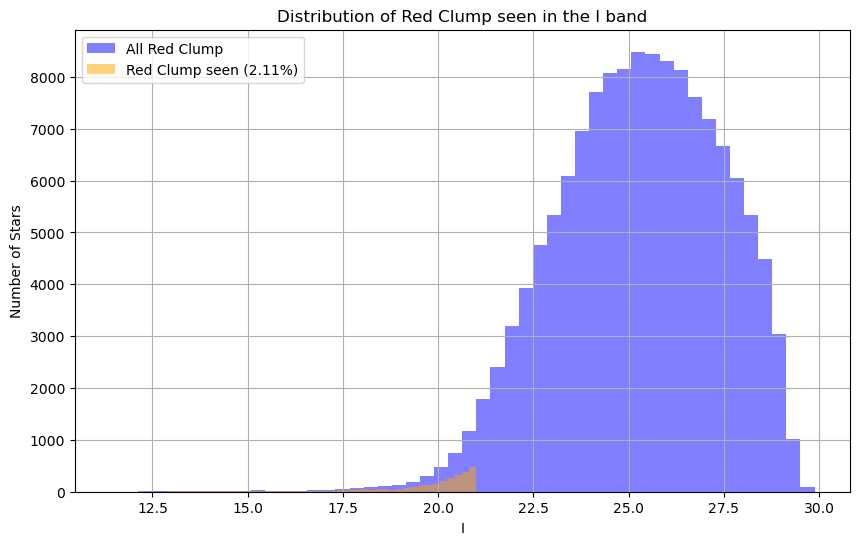

In [12]:
plt.figure(figsize=(10,6))

plt.hist(RC["V"].values - RC["V-I"].values, bins=50, alpha=0.5, label='All Red Clump', color='blue')
plt.hist(RC_I_seen["V"].values - RC_I_seen["V-I"].values, bins=50, alpha=0.5, label=f'Red Clump seen ({percentage:.2f}%)', color='orange')
#plt.hist(df_fits_native["V"].values - df_fits_native["V-J"].values, bins=50, alpha=0.5, label='All Stars', color='green')

plt.xlabel('I')
plt.ylabel('Number of Stars')
plt.title('Distribution of Red Clump seen in the I band')
plt.legend()
plt.grid()
plt.show()

# Starcounts per differenti limiti sulle bande J, I e V per le Red Clump

Calcolo ora il numero di RC con 
 - J < 19 e I < 21
 - J < 19, I < 21 e V < 20.

In [13]:
# Filtro le RC già filtrate per J < 19 con i nuovi filtri in I e in V
RC_J_I = RC_J[(RC_J["V"] - RC_J["V-I"]) < 21].copy() #J < 19, I < 21
print(f"The number of RC with J < 19 and I < 21 is: {len(RC_J_I)}. This is {len(RC_J_I)/len(RC_J)*100:.2f}% of the total RC with J < 19.")

The number of RC with J < 19 and I < 21 is: 3610. This is 5.39% of the total RC with J < 19.


Since this is the same number of RC with I < 21, we understand that the 100% of RC with a cut on I < 21, have already a cut on J < 19.
This is proved in the following when the conditions on the bands are inverted.

In [14]:
RC_I_J = RC_I[(RC_I["V"] - RC_I["V-J"]) < 19].copy() #I < 21, J < 19
print(f"The number of RC with I < 21 and J < 19 is: {len(RC_I_J)}. This is {len(RC_I_J)/len(RC_I)*100:.2f}% of the total RC with I < 21.")

The number of RC with I < 21 and J < 19 is: 3610. This is 100.00% of the total RC with I < 21.


In [15]:
# e infine filtro le RC già filtrate per J < 19 e I < 21 con i nuovi filtri in V
RC_J_I_V = RC_J_I[RC_J_I["V"] < 20].copy() #J < 19, I < 21, V < 20
print(
    f"The number of RC with J < 19, I < 21 and V < 20 is: {len(RC_J_I_V)}.\n"
    f"This is {len(RC_J_I_V)/len(RC_J_I)*100:.2f}% of the total RC with J < 19 and I < 21 and just {len(RC_J_I_V)/len(RC_J)*100:.2f}% of the total RC with J < 19."
)

The number of RC with J < 19, I < 21 and V < 20 is: 184.
This is 5.10% of the total RC with J < 19 and I < 21 and just 0.27% of the total RC with J < 19.


Compio ora lo stesso conto ma per le RC che possono essere viste, ovvero quelle con J < 19 e che non hanno stelle vicine luminose (RC_J_seen).

In [16]:
RC_J_I_seen = RC_J_seen[RC_J_seen["V"] - RC_J_seen["V-I"] < 21].copy() #J < 19, I < 21
print(
    f"The number of resolved RC by Euclid with I < 21 and J < 19 is: {len(RC_J_I_seen)}.\n"
    f"This is {len(RC_J_I_seen)/len(RC_J_seen)*100:.2f}% of the total RC with J < 19 not covered by other stars.")

The number of resolved RC by Euclid with I < 21 and J < 19 is: 3459.
This is 5.80% of the total RC with J < 19 not covered by other stars.


Stessa cosa aggiungendo il vincolo su V.

In [17]:
RC_J_I_V_seen = RC_J_I_seen[RC_J_I_seen["V"] < 20].copy() #J < 19, I < 21, V < 20
print(
    f"The number of RC detectable by Euclid with V < 20, I < 21 and J < 19 is: {len(RC_J_I_V_seen)}.\n"
    f"This is {len(RC_J_I_V_seen)/len(RC_J_seen)*100:.2f}% of the total RC with J < 19 not covered by other stars.")

The number of RC detectable by Euclid with V < 20, I < 21 and J < 19 is: 183.
This is 0.31% of the total RC with J < 19 not covered by other stars.


Creo ora una funzione che dato un dataset, resituisca le stelle appartenenti al Thin disk o al bulge:

- Pop = 10 (bulge)
- Pop < 8 (thin disk)

In [18]:
def pop_filter(df):
    thin = df[df["Pop"] < 8] #thin disk
    bulge = df[df["Pop"] == 10] #bulge
    return thin, bulge

Dunque dato un dataset df, ho:
- pop_filter(df)[0] = Thin Disk
- pop_filter(df)[1] = Bulge

# Grafici di J vs N e J vs N'/N.

Come prima cosa, creo il grafico J vs N, con N la percentuale di RC con un determinato vincolo, tra quelli impostati prima. 

In [19]:
def N(df, j):
    """
    Returns the percentage of stars in the DataFrame df with J < j with respect to the number of RC with J < 19.
    """
    return len(df[df["V"] - df["V-J"] < j]) / len(RC_J) * 100


In [20]:
def Num(df, j):
    """
    Returns the  number of stars in the DataFrame df with J < j
    """
    return len(df[df["V"] - df["V-J"] < j])

Faccio un test per vedere se i valori che ottengo con j = 19 corrispondono ai valori calcolati in precedenza.

In [21]:
print(f"Percentage of RC with J < 19: {N(RC, 19):.2f}%")
print(N(RC_J_I, 19))
print(N(RC_J_I_V, 19))

Percentage of RC with J < 19: 100.00%
5.388622691923037
0.2746555610287642


Tutto giusto.

Plot della funzione N in base a J per i diversi vincoli.

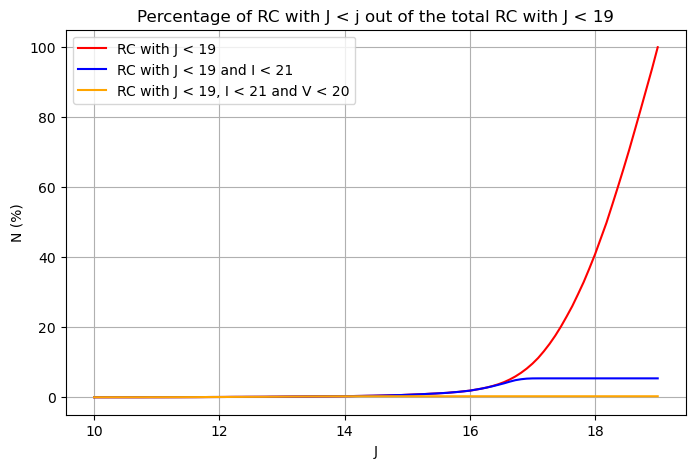

In [22]:
J = np.linspace(10, 19, 100) 

plt.figure(figsize=(8,5))
#plt.plot(J, [N(RC, j) for j in J], label='All RC', color='blue')
plt.plot(J, [N(RC_J, j) for j in J], label='RC with J < 19', color='red')
plt.plot(J, [N(RC_J_I, j) for j in J], label='RC with J < 19 and I < 21', color='blue')
plt.plot(J, [N(RC_J_I_V, j) for j in J], label='RC with J < 19, I < 21 and V < 20', color='orange')

plt.xlabel('J')
plt.ylabel('N (%)')
#plt.yscale('log')  
plt.title("Percentage of RC with J < j out of the total RC with J < 19")
plt.grid()
plt.legend()
plt.show()


Ora faccio lo stesso grafico ma con il numero effettivo di stelle (e non la percentuale) e la scala logaritmica

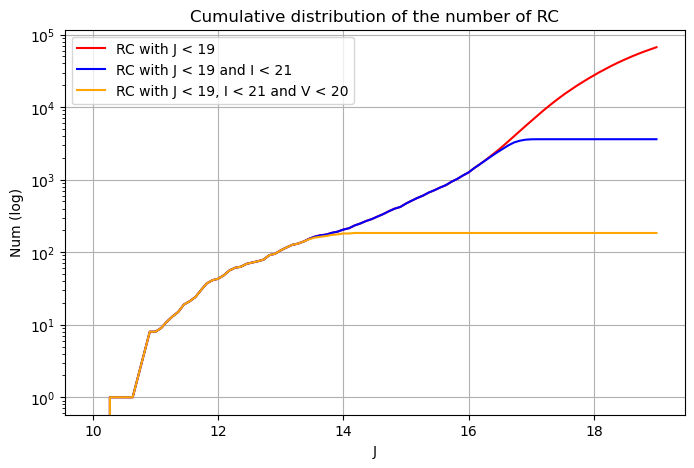

In [23]:
J = np.linspace(10, 19, 100) 

plt.figure(figsize=(8,5))
#plt.plot(J, [N(RC, j) for j in J], label='All RC', color='blue')
plt.plot(J, [Num(RC_J, j) for j in J], label='RC with J < 19', color='red')
plt.plot(J, [Num(RC_J_I, j) for j in J], label='RC with J < 19 and I < 21', color='blue')
plt.plot(J, [Num(RC_J_I_V, j) for j in J], label='RC with J < 19, I < 21 and V < 20', color='orange')

plt.xlabel('J')
plt.ylabel('Num (log)')
plt.yscale('log')  
plt.title("Cumulative distribution of the number of RC")
plt.grid()
plt.legend()
plt.show()

E ora, il grafico di J vs N'/N

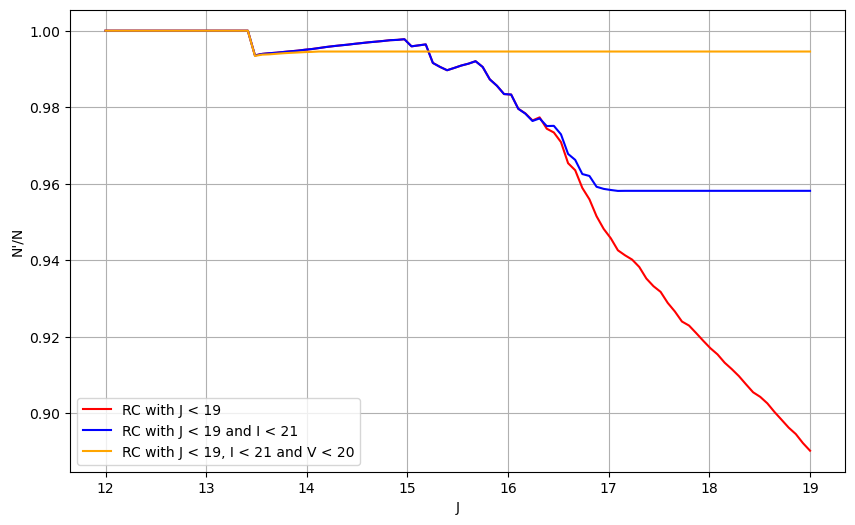

In [24]:
J1 = np.linspace(12, 19, 100)
plt.figure(figsize=(10,6))
#plt.plot(J, [N(RC, j) for j in J], label='All RC', color='blue')
plt.plot(J1, [N(RC_J_seen, j)/N(RC_J, j) for j in J1], label='RC with J < 19', color='red')
plt.plot(J1, [N(RC_J_I_seen, j)/N(RC_J_I, j) for j in J1], label='RC with J < 19 and I < 21', color='blue')
plt.plot(J1, [N(RC_J_I_V_seen, j)/N(RC_J_I_V, j) for j in J1], label='RC with J < 19, I < 21 and V < 20', color='orange')

plt.xlabel('J')
plt.ylabel('N\'/N')
plt.grid()
plt.legend()
plt.show()

Faccio ora gli stessi grafici ma differenziali e non cumulativi, ovvero invece che considerare il numero totale di RC sotto una certa fascia, calcolo il numero per un certo bin della magnitudine. 

Modifico dunque la funzione che calcola il numero di stelle e la adatto per il calcolo in diversi bin.

In [25]:
def Num_bin(df, j, bin_size):
    """
    Returns the number of stars in the DataFrame df with J in the interval [j - bin_size/2, j + bin_size/2).
    """
    J_mag = df["V"] - df["V-J"]
    lower = j - bin_size / 2
    upper = j + bin_size / 2
    return len(df[(J_mag >= lower) & (J_mag < upper)])

In [26]:
def N_bin_seen(df, j, bin_size):
    """
    Returns the percentage of stars in a DataFrame df with J in the interval [j - bin_size/2, j + bin_size/2]
    with respect to the number of RC with J < 19.
    """
    J_mag = df["V"] - df["V-J"]
    lower = j - bin_size / 2
    upper = j + bin_size / 2
    return len(df[(J_mag >= lower) & (J_mag < upper)]) / len(df) 

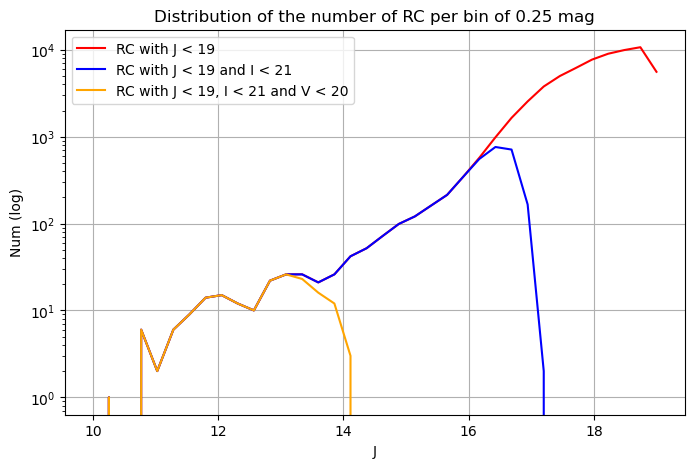

In [27]:
bin = 0.25
start = 10
end = 19
num_of_bins = int((end - start) / bin)
J = np.linspace(start, end, num_of_bins)


plt.figure(figsize=(8,5))
#plt.plot(J, [N(RC, j) for j in J], label='All RC', color='blue')
plt.plot(J, [Num_bin(RC_J, j, bin) for j in J], label='RC with J < 19', color='red')
plt.plot(J, [Num_bin(RC_J_I, j, bin) for j in J], label='RC with J < 19 and I < 21', color='blue')
plt.plot(J, [Num_bin(RC_J_I_V, j, bin) for j in J], label='RC with J < 19, I < 21 and V < 20', color='orange')

plt.xlabel('J')
plt.ylabel('Num (log)')
plt.yscale('log')  
plt.title(f"Distribution of the number of RC per bin of {bin} mag")
plt.grid()
plt.legend()
plt.show()

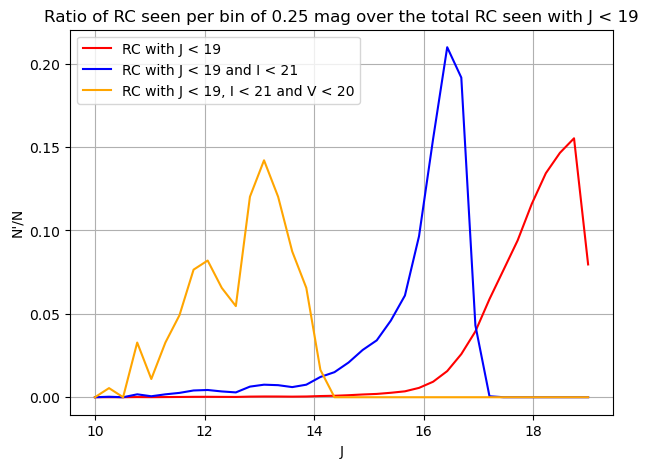

In [28]:
plt.figure(figsize=(7,5))
#plt.plot(J, [N(RC, j) for j in J], label='All RC', color='blue')
plt.plot(J, [N_bin_seen(RC_J_seen, j, bin) for j in J], label='RC with J < 19', color='red')
plt.plot(J, [N_bin_seen(RC_J_I_seen, j, bin) for j in J], label='RC with J < 19 and I < 21', color='blue')
plt.plot(J, [N_bin_seen(RC_J_I_V_seen, j, bin) for j in J], label='RC with J < 19, I < 21 and V < 20', color='orange')

plt.xlabel('J')
plt.ylabel('N\'/N')
#plt.yscale('log')
plt.title(f"Ratio of RC seen per bin of {bin} mag over the total RC seen with J < 19")
plt.grid()
plt.legend()
plt.show()

# MAKE NOTEBOOK IMPORTABLE

As last thing, I make all the dataset created (with the different cut) importable to other notebooks so that I can make shorter notebooks.

First, we need to define a function giving the galactic radius R of the star (distance from the center) and the rotational velocity R_phi.

In [29]:
# Calcolo delle coordinate galattiche e velocità in coordinate galattiche per i dataset contenenti le RC effettivamente viste
# con i 3 diversi filtri

all_J = df_fits_native[df_fits_native["V"] - df_fits_native["V-J"] < 19] # All stars with J < 19
bulge_J = pop_filter(all_J)[1] # Bulge stars with J < 19

data = [df_fits,
        all_J,
        bulge_J,
        RC_J_seen,
        RC_J_I_seen,
        RC_J_I_V_seen, 
        pop_filter(RC_J_seen)[0], # resolved Red clump with J < 19 from the thin disk
        pop_filter(RC_J_seen)[1], # resolved Red clump with J < 19 from the bulge
        pop_filter(RC_J_I_seen)[0], # resolved Red clump with J < 19 and I < 21 from the thin disk
        pop_filter(RC_J_I_seen)[1], # resolved Red clump with J < 19 and I < 21 from the bulge
        RC # all the Red Clump stars 
        ]

for i in range(len(data)):
    df = data[i]
    # Make sure to work on a copy to avoid chained assignment
    df = df.copy()

    # tramuto il sistema di coordinate galattihe da right handed (Besancon) a left handed 
    # per poter usare le formule di velocità delle slide di Spagna
    df.loc[:, "x_Gal"] = -df["x_Gal"]
    df.loc[:, "UU"] = -df["UU"]
    V_LSR = 244.6
    R_sun = 8

    df.loc[:, "R"] = np.sqrt(df["x_Gal"]**2 + df["y_Gal"]**2)
    phi = np.arctan2(df["y_Gal"], df["x_Gal"])
    df.loc[:, "V_y"] = df["VV"] + V_LSR
    df.loc[:, "V_phi"] = df["V_y"] * np.cos(phi) - df["UU"] * np.sin(phi)
    df.loc[:, "V_R"] = df["V_y"] * np.sin(phi) + df["UU"] * np.cos(phi)
    data[i] = df

In [30]:
import joblib

for i, df in enumerate(data):
    joblib.dump(df, f'data_{i}.joblib')